# 02. Setting A — 일별 21일 누적 수익률 예측

**Phase 1 — Step 2: LSTM × ETF × 일별(21영업일 뒤) 설정**

## 이 노트북의 역할

| 절 | 내용 | 상태 |
|---|---|---|
| §1 | 환경 설정 (`00_setup_and_utils.ipynb` %run) | ✅ |
| §2 | 데이터 로드 (SPY·QQQ 일별 log-return, 분석 기간 2016–2025) | ✅ |
| §3 | 타깃 생성 (`scripts/targets.py` — 21일 누적 forward log-return) | ✅ |
| §4 | 누수 검증 2종 (assert + 육안 표) | ✅ |
| §5 | `LSTMDataset` + `make_sequences` 검증 (seq_len=**126**) | ✅ |
| §6 | Walk-Forward fold 생성 (IS=231, purge=21, emb=21, OOS=21, step=21) | ✅ |
| §7 | LSTMRegressor import — TODO (`scripts/models.py` 필요) | 🔜 |
| §8 | 학습 루프 — TODO (`scripts/train.py` 필요) | 🔜 |
| §9 | 평가·시각화 — TODO (`scripts/metrics.py`, `scripts/plot_utils.py` 필요) | 🔜 |
| §10 | 결론·체크포인트 | 🔜 |

## 설정 A 사양 (PLAN.md 확정값)

| 항목 | 값 |
|------|---|
| 타깃 | 21영업일 후 누적 log-return |
| seq_len | **126** (약 6개월 lookback) |
| hidden_size | 128 |
| num_layers | 2 |
| dropout | 0.2 |
| IS | 231 영업일 (~11개월) |
| OOS | 21 영업일 (~1개월) |

## 누수 방지 설계

- **타깃**: `log_ret.rolling(21).sum().shift(-21)` — 미래 21일 합 (예측 목표, §4 검증)
- **Scaler**: `StandardScaler.fit()` 은 **훈련 구간(train_idx)** 만 사용, val·test는 transform만
- **Walk-Forward**: Purge(21) + Embargo(21) — IS 끝과 OOS 사이 42일 gap 보장
- **테스트 입력 lookback**: purge/embargo 구간과 겹쳐도 **입력 피처**이므로 허용

## 진실원

유틸리티 구현:
- [scripts/targets.py](scripts/targets.py) — 타깃 생성·누수 검증
- [scripts/dataset.py](scripts/dataset.py) — LSTMDataset, make_sequences, walk_forward_folds, build_fold_datasets

## §1. 환경 설정 로드

**무엇을**: `00_setup_and_utils.ipynb` 의 공통 설정을 한 줄로 로드한다.

**왜 이 방식**: 한글 폰트·시드·경로 상수(`RAW_DATA_DIR`, `RESULTS_DIR` 등)를 모든 노트북에서
중복 없이 재사용하기 위해 `%run` 패턴을 사용한다.

**주의**: `%run` 은 노트북의 모든 셀을 순서대로 실행하므로 부작용(side-effect)이 있는 셀이
없어야 한다. `00_setup_and_utils.ipynb` 는 순수 설정 코드만 포함하도록 관리한다.

In [3]:
%run ./00_setup_and_utils.ipynb

[OK] scripts.setup import 완료 — BASE_DIR = C:\Users\gorhk\최종프로젝트\finance_project\시계열_Test\Phase1_LSTM
[OK] 한글 폰트 설정 완료: Malgun Gothic
[OK] 시드 고정 완료: SEED=42
[정보] PyTorch 버전: 2.11.0+cu126, CUDA 가용: False
[OK] 경로 상수 확인
  BASE_DIR      = C:\Users\gorhk\최종프로젝트\finance_project\시계열_Test\Phase1_LSTM
  RAW_DATA_DIR  = C:\Users\gorhk\최종프로젝트\finance_project\시계열_Test\Phase1_LSTM\results\raw_data
  SETTING_A_DIR = C:\Users\gorhk\최종프로젝트\finance_project\시계열_Test\Phase1_LSTM\results\setting_A
  SETTING_B_DIR = C:\Users\gorhk\최종프로젝트\finance_project\시계열_Test\Phase1_LSTM\results\setting_B
[OK] 공통 import + 표시 옵션 적용 완료
  pandas 2.3.3, numpy 2.4.4
  Phase 1 — LSTM 단독 베이스라인 / 환경 설정 완료
  한글 폰트  : AppleGothic
  시드       : 42
  결과 경로  : C:\Users\gorhk\최종프로젝트\finance_project\시계열_Test\Phase1_LSTM\results
  진실원     : scripts/setup.py


## §2. 데이터 로드

**무엇을**: `01_data_download_and_eda.ipynb` 가 저장한 SPY·QQQ CSV를 읽고
분석 기간(2016-01-01 ~ 2025-12-31)으로 절단한다.

**왜 전체 기간에서 먼저 log_return 계산**: 분석 시작일(2016-01-04)의 log_return이
직전 거래일(2015-12-31) 대비로 올바르게 계산되어야 한다.
분석 기간 절단 *후* diff() 를 하면 시작일에 NaN이 생긴다.

**대안과 트레이드오프**: `Adj Close` 대신 `Close` 를 쓰면 배당·액면분할이 반영되지
않아 log-return 이 불연속 점프를 포함한다 → Adj Close 사용이 옳다.

**함정**: `parse_dates=True` 없이 읽으면 인덱스가 문자열 → `.loc[날짜:]` 슬라이싱 실패.

In [4]:
ANALYSIS_START = '2016-01-01'
ANALYSIS_END   = '2025-12-31'

raw_dict = {}
for tic in ['SPY', 'QQQ']:
    df = pd.read_csv(RAW_DATA_DIR / f'{tic}.csv', index_col=0, parse_dates=True)
    df['log_return'] = np.log(df['Adj Close']).diff()  # 누수: 전체 기간에서 diff → 시작일 NaN 방지
    raw_dict[tic] = df.loc[ANALYSIS_START:ANALYSIS_END]

print(f'{"티커":>6}  {"행수":>6}  {"NaN":>4}  {"시작일":>12}  {"종료일":>12}')
print('-' * 55)
for tic, df in raw_dict.items():
    lr = df['log_return']
    print(f'{tic:>6}  {len(df):>6}  {lr.isna().sum():>4}  '
          f'{str(df.index[0].date()):>12}  {str(df.index[-1].date()):>12}')

    티커      행수   NaN           시작일           종료일
-------------------------------------------------------
   SPY    2514     0    2016-01-04    2025-12-31
   QQQ    2514     0    2016-01-04    2025-12-31


## §3. 타깃 생성 — 21일 누적 forward log-return

**무엇을**: Setting A 의 예측 대상인 **21영업일 후 누적 log-return** 을 생성한다.

**왜 21일**: 미국 시장의 평균 영업월(~21 거래일)에 맞춰 월별 리밸런싱 예측을 수행한다.

**공식**:
```
log_ret[t] = log(Adj_Close[t]) - log(Adj_Close[t-1])
target[t]  = Σ log_ret[t+k], k=1..21
           = log_ret.rolling(21).sum().shift(-21)
```

**왜 `.shift(-21)` 인가**:
```
rolling(21).sum() 는 과거 trailing 합 (t-20 ~ t)
.shift(-21)       은 21일 앞으로 당겨서 → 위치 t에 t+1~t+21 합을 배치
```

**shift 부호 그림**:
```
날짜:   ...  t-20  ...  t   t+1  ...  t+21  ...
rolling sum: [t-20~t 합]  ← trailing
.shift(-21): 이 값이 t-21 위치로 이동 → t 위치에는 [t+1~t+21 합]
```

**이것이 누수인가?**: target[t] 자체는 미래값을 포함하지만, 모델이 t 이전 데이터만
입력으로 받으면 누수가 아니다. §6의 Walk-Forward Purge+Embargo가 이를 보장한다.

**NaN 발생 위치**:
- 첫 1행: log_ret.diff() 계산
- 마지막 21행: 미래 21일 데이터 부족

In [5]:
from scripts.targets import build_daily_target_21d

targets_dict = {}
for tic, df in raw_dict.items():
    target = build_daily_target_21d(df['Adj Close'])
    targets_dict[tic] = target
    valid = target.notna().sum()
    print(f'{tic}: 유효 타깃 {valid}개  '
          f'(NaN {target.isna().sum()}개 — 첫 1행 + 마지막 21행 제거 예상)')

print()
print('SPY 타깃 앞 5행 (NaN 포함):')
print(targets_dict['SPY'].head())
print()
print('SPY 타깃 뒤 5행 (NaN 확인):')
print(targets_dict['SPY'].tail())

SPY: 유효 타깃 2493개  (NaN 21개 — 첫 1행 + 마지막 21행 제거 예상)
QQQ: 유효 타깃 2493개  (NaN 21개 — 첫 1행 + 마지막 21행 제거 예상)

SPY 타깃 앞 5행 (NaN 포함):
date
2016-01-04   -0.049562
2016-01-05   -0.049684
2016-01-06   -0.056224
2016-01-07   -0.045493
2016-01-08   -0.034401
Name: Adj Close, dtype: float64

SPY 타깃 뒤 5행 (NaN 확인):
date
2025-12-24   NaN
2025-12-26   NaN
2025-12-29   NaN
2025-12-30   NaN
2025-12-31   NaN
Name: Adj Close, dtype: float64


## §4. 누수 검증 — 2종 체크포인트

**무엇을**: 타깃 시계열이 미래 데이터를 *의도치 않게* 입력에 흘리지 않음을 확인한다.

**왜 2종**: López de Prado(2018) 기준으로 단위 테스트 + 육안 확인을 수행한다.
원 계획의 "인공 누수 대조 sanity check" 는 `scripts/*.py` 단위 테스트로 이미 파이프라인 정상성이 확인되어 있어 제거되었다 (2026-04-25).

**검증 1**: `assert target[t] == log_ret[t+1:t+22].sum()` — 수치 일치 확인

**검증 2**: 첫 5개 유효 행의 날짜·log_ret·target·직접계산값을 나란히 출력 — 사람이 육안 확인

In [6]:
# 검증 1·2 — assert 단위 테스트 + 육안 확인 표
from scripts.targets import verify_no_leakage

for tic, df in raw_dict.items():
    print(f'\n{'='*60}')
    print(f'  [{tic}] 누수 검증')
    print(f'{'='*60}')
    log_ret = df['log_return'].dropna()          # 분석 기간 내 NaN 없음 (§2에서 확인)
    target  = targets_dict[tic]
    verify_no_leakage(log_ret, target, n_checks=3, seed=42)


  [SPY] 누수 검증
=== 누수 검증 1 — Assert 단위 테스트 ===
  [PASS] 2016-11-17  target=0.035304  직접계산=0.035304  Δ=0.00e+00
  [PASS] 2022-06-27  target=0.031536  직접계산=0.031536  Δ=0.00e+00
  [PASS] 2023-08-31  target=-0.048994  직접계산=-0.048994  Δ=0.00e+00

=== 누수 검증 2 — 육안 확인 표 (첫 5개 유효 행) ===
            날짜     log_ret      target        직접계산    일치
  ------------------------------------------------------
    2016-01-04   -0.014078   -0.049562   -0.049562     O
    2016-01-05    0.001689   -0.049684   -0.049684     O
    2016-01-06   -0.012694   -0.056224   -0.056224     O
    2016-01-07   -0.024284   -0.045493   -0.045493     O
    2016-01-08   -0.011037   -0.034401   -0.034401     O

[OK] 누수 검증 완료 — 모든 체크포인트 PASS

  [QQQ] 누수 검증
=== 누수 검증 1 — Assert 단위 테스트 ===
  [PASS] 2016-11-17  target=0.022546  직접계산=0.022546  Δ=0.00e+00
  [PASS] 2022-06-27  target=0.047935  직접계산=0.047935  Δ=0.00e+00
  [PASS] 2023-08-31  target=-0.043823  직접계산=-0.043823  Δ=0.00e+00

=== 누수 검증 2 — 육안 확인 표 (첫 5개 유효 행) ===
          

## §5. `LSTMDataset` · `make_sequences` — Setting A 파라미터 검증

**무엇을**: `scripts/dataset.py` 의 공개 인터페이스를 로드하고 Setting A 파라미터로 검증한다.

**Setting A `seq_len = 126` (약 6개월 lookback)**: PLAN.md 확정 사양.

**각 샘플 구조**:
```
X[i] = log_return[i : i+126]         # 과거 126일 수익률 시퀀스  shape: (126, 1)
y[i] = target_21d[i+125]             # i+125 일 기준 21일 누적 forward 수익률
```

**폴드별 훈련 샘플 수**:
```
N_train = IS − seq_len = 231 − 126 = 105  (폴드당)
```

**⚠️ (B, T, F) 축 계약 (학습자료_주의사항 §3.3)**:

DataLoader 출력은 `(B, T, F) = (batch, 126, 1)` 형태다.  
PyTorch LSTM의 기본값은 `batch_first=False` → `(T, B, F)` 입력을 기대.  
**`LSTMRegressor` 는 반드시 `batch_first=True` 로 초기화해야 DataLoader 출력과 일치한다.**  
→ `output[:, -1, :]` (마지막 시점 hidden 추출) 도 `batch_first=True` 기준 인덱스임.

| 함수 / 클래스 | 역할 |
|---|---|
| `LSTMDataset` | `(X, y)` 텐서를 보관하는 `torch.utils.data.Dataset` |
| `make_sequences` | 1D/2D 시계열 → 슬라이딩 윈도우 `(X, y)` |
| `walk_forward_folds` | Walk-Forward 폴드 인덱스 목록 생성 |
| `build_fold_datasets` | 폴드 하나의 스케일링 + `LSTMDataset` 일괄 생성 |

In [7]:
from scripts.dataset import (
    LSTMDataset,
    make_sequences,
    walk_forward_folds,
    build_fold_datasets,
)
from torch.utils.data import DataLoader

print('[OK] scripts.dataset import 완료')

[OK] scripts.dataset import 완료


In [8]:
# Setting A 파라미터
SEQ_LEN = 126  # 약 6개월 lookback — PLAN.md 확정값

spy_lr  = raw_dict['SPY']['log_return'].values   # shape (2514,), NaN 없음
qqq_lr  = raw_dict['QQQ']['log_return'].values
spy_tgt = targets_dict['SPY'].values             # shape (2514,), 마지막 21행 NaN

# make_sequences 로 X만 생성해 형태 확인 (y는 target_series 에서 별도 추출)
X_spy, _ = make_sequences(spy_lr, seq_len=SEQ_LEN)

print(f'make_sequences(spy_lr, seq_len={SEQ_LEN}) 결과')
print(f'  X.shape = {X_spy.shape}   → (N, seq_len={SEQ_LEN}, n_features=1)')
print()
print(f'Setting A 폴드별 훈련 샘플 수 (IS=231, seq_len=126):')
print(f'  N_train = IS − seq_len = 231 − 126 = {231 - SEQ_LEN}')
print(f'  N_test  = OOS = 21')
print()
# 정렬 검증: X[0] 마지막 값 = spy_lr[125], target[0] = spy_tgt[125]
print(f'정렬 검증:')
print(f'  X[0][-1] == spy_lr[{SEQ_LEN-1}] → {X_spy[0][-1, 0]:.6f} == {spy_lr[SEQ_LEN-1]:.6f}')
print(f'  target[{SEQ_LEN-1}] (21일 누적 수익률) = {spy_tgt[SEQ_LEN-1]:.6f}')

make_sequences(spy_lr, seq_len=126) 결과
  X.shape = (2388, 126, 1)   → (N, seq_len=126, n_features=1)

Setting A 폴드별 훈련 샘플 수 (IS=231, seq_len=126):
  N_train = IS − seq_len = 231 − 126 = 105
  N_test  = OOS = 21

정렬 검증:
  X[0][-1] == spy_lr[125] → 0.002098 == 0.002098
  target[125] (21일 누적 수익률) = 0.026467


## §6. Walk-Forward fold 생성

**무엇을**: Setting A 의 Walk-Forward 교차검증 폴드 인덱스를 생성하고 검증한다.

**왜 Walk-Forward + Purge + Embargo** (López de Prado 2018 근거):
- **단순 K-Fold 의 문제**: 시계열에서 미래 데이터가 훈련에 포함되어 성능 과대평가
- **Purge(21)**: Setting A 타깃은 21일 forward 합 → IS 끝 21일의 타깃이 OOS 가격을 참조
  → IS 끝 21일을 학습에서 제거해 레이블 겹침 차단
- **Embargo(21)**: IS 직후 구간에 lookback(seq_len=126) autocorrelation 잔존 가능성
  → 추가 21일 공백으로 OOS 성능 부풀림 방지

**폴드 구조**:
```
날짜 축 →
Fold k: ├── IS (231일) ──┤ purge(21) │ emb(21) │ OOS(21) ┤
                                                 ↑ step=21 씩 이동
```

**파라미터**:

| 구성 | 값 | 의미 |
|---|---|---|
| IS | 231 | 훈련 구간 (~11개월) |
| purge | 21 | 레이블 겹침 제거 |
| emb | 21 | autocorrelation 차단 |
| OOS | 21 | 테스트 구간 (~1개월) |
| step | 21 | 폴드 이동 간격 |

**예상 폴드 수**: ⌊(2514 − 294) / 21⌋ = **106**

**IS 내 train/val 재분할** (§8에서 EarlyStopping 용):
- train: IS의 80% = 184일 → 시퀀스 수 = 184 − seq_len = 184 − 126 = 58
- val: IS의 20% = 47일 → 시퀀스 수 = 47 − seq_len = 47 − 126 = **음수!**
  → val 크기 조정 필요: IS 내부 분할 시 `gap = seq_len` 적용 후
    train=IS−seq_len−val_size, val=val_size (val_size는 고정값 사용, 비율 대신)
    (§8 train.py 작성 시 결정)

In [9]:
IS, PURGE, EMB, OOS, STEP = 231, 21, 21, 21, 21
n_samples = len(spy_lr)  # 2514

folds = walk_forward_folds(n_samples, IS, PURGE, EMB, OOS, STEP)
print(f'총 폴드 수: {len(folds)}')
print()

dates = raw_dict['SPY'].index

print(f'{"폴드":>4}  {"train 시작":>12}  {"train 끝":>12}  {"test 시작":>12}  {"test 끝":>12}')
print('-' * 65)
for fold_i in [0, 1, 2, len(folds) - 1]:
    tr, te = folds[fold_i]
    print(f'{fold_i:>4}  {str(dates[tr[0]].date()):>12}  {str(dates[tr[-1]].date()):>12}  '
          f'{str(dates[te[0]].date()):>12}  {str(dates[te[-1]].date()):>12}')

print()
tr0, te0 = folds[0]
print(f'[폴드 0 상세]')
print(f'  train 인덱스: {tr0[0]}~{tr0[-1]}  ({len(tr0)}일)')
print(f'  test  인덱스: {te0[0]}~{te0[-1]}  ({len(te0)}일)')
print(f'  gap (purge+emb): {te0[0] - tr0[-1] - 1}일')
print(f'  훈련 시퀀스 수 (IS − seq_len): {IS - SEQ_LEN}')
print(f'  테스트 입력 lookback 시작: {te0[0] - SEQ_LEN} (purge/emb 구간 포함, 허용)')

총 폴드 수: 106

  폴드      train 시작       train 끝       test 시작        test 끝
-----------------------------------------------------------------
   0    2016-01-04    2016-11-30    2017-02-02    2017-03-03
   1    2016-02-03    2016-12-30    2017-03-06    2017-04-03
   2    2016-03-04    2017-02-01    2017-04-04    2017-05-03
 105    2024-10-08    2025-09-10    2025-11-10    2025-12-09

[폴드 0 상세]
  train 인덱스: 0~230  (231일)
  test  인덱스: 273~293  (21일)
  gap (purge+emb): 42일
  훈련 시퀀스 수 (IS − seq_len): 105
  테스트 입력 lookback 시작: 147 (purge/emb 구간 포함, 허용)


In [10]:
# 폴드 0 — build_fold_datasets 로 텐서 생성 검증 (target_series 사용)
train_idx_0, test_idx_0 = folds[0]

train_ds, test_ds, scaler = build_fold_datasets(
    spy_lr, train_idx_0, test_idx_0, SEQ_LEN,
    target_series=spy_tgt,  # 21일 누적 forward log-return
)

print('=== 폴드 0 텐서 형태 (Setting A: seq_len=126, target=21일 누적) ===')
print(f'train_ds.X : {tuple(train_ds.X.shape)}   (N_train, seq_len, n_feat)')
print(f'train_ds.y : {tuple(train_ds.y.shape)}')
print(f'test_ds.X  : {tuple(test_ds.X.shape)}    (N_test, seq_len, n_feat)')
print(f'test_ds.y  : {tuple(test_ds.y.shape)}')
print()
print('[스케일러 — 훈련 구간 기준 (입력 피처 전용)]')
print(f'  mean  = {scaler.mean_[0]:.8f}   (log_return 평균)')
print(f'  scale = {scaler.scale_[0]:.8f}  (log_return 표준편차)')
print()
print('[타깃 통계 — 비정규화 (21일 누적 수익률)]')
print(f'  train y mean  = {train_ds.y.mean().item():.6f}')
print(f'  train y std   = {train_ds.y.std().item():.6f}')
print(f'  test  y mean  = {test_ds.y.mean().item():.6f}')
print()
print('[텐서 dtype]')
print(f'  X dtype: {train_ds.X.dtype}  (float32 필요)')
print(f'  y dtype: {train_ds.y.dtype}')

=== 폴드 0 텐서 형태 (Setting A: seq_len=126, target=21일 누적) ===
train_ds.X : (105, 126, 1)   (N_train, seq_len, n_feat)
train_ds.y : (105,)
test_ds.X  : (21, 126, 1)    (N_test, seq_len, n_feat)
test_ds.y  : (21,)

[스케일러 — 훈련 구간 기준 (입력 피처 전용)]
  mean  = 0.00040364   (log_return 평균)
  scale = 0.00845723  (log_return 표준편차)

[타깃 통계 — 비정규화 (21일 누적 수익률)]
  train y mean  = 0.010401
  train y std   = 0.021910
  test  y mean  = 0.011888

[텐서 dtype]
  X dtype: torch.float32  (float32 필요)
  y dtype: torch.float32


In [11]:
# DataLoader 배치 검증
# shuffle=True  → 훈련 시 시간 순서 무작위화 (LSTM 학습 관행)
# shuffle=False → 테스트 시 시간 순서 보존
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=len(test_ds), shuffle=False)

print(f'train_loader: {len(train_loader)} 배치 (batch_size={BATCH_SIZE}, N={len(train_ds)})')
print(f'test_loader : {len(test_loader)} 배치  (전체 한 번에)')
print()

for xb, yb in train_loader:
    print(f'[train 첫 배치] X: {tuple(xb.shape)},  y: {tuple(yb.shape)},  dtype: {xb.dtype}')
    break

for xb, yb in test_loader:
    print(f'[test  전체  ] X: {tuple(xb.shape)},  y: {tuple(yb.shape)}')

train_loader: 4 배치 (batch_size=32, N=105)
test_loader : 1 배치  (전체 한 번에)

[train 첫 배치] X: (32, 126, 1),  y: (32,),  dtype: torch.float32
[test  전체  ] X: (21, 126, 1),  y: (21,)


In [12]:
# 전체 106 폴드 일괄 검증 (SPY)
n_train_list, n_test_list = [], []

for tr_idx, te_idx in folds:
    tr_ds, te_ds, _ = build_fold_datasets(
        spy_lr, tr_idx, te_idx, SEQ_LEN, target_series=spy_tgt
    )
    n_train_list.append(len(tr_ds))
    n_test_list.append(len(te_ds))

print(f'총 {len(folds)} 폴드 정상 생성 완료 (SPY, seq_len={SEQ_LEN})')
print(f'train 샘플 수: 고정={len(set(n_train_list)) == 1},  값={n_train_list[0]}')
print(f'test  샘플 수: 고정={len(set(n_test_list)) == 1},   값={n_test_list[0]}')

총 106 폴드 정상 생성 완료 (SPY, seq_len=126)
train 샘플 수: 고정=True,  값=105
test  샘플 수: 고정=True,   값=21


## §7. LSTMRegressor import — TODO

**필요 파일**: `scripts/models.py`

**구현 예정 내용** (PLAN.md §7):
```python
from scripts.models import LSTMRegressor

# ⚠️ batch_first=True 필수 (학습자료_주의사항 §3.3)
# DataLoader → (B, T, F) = (32, 126, 1)
# LSTM 기본값 batch_first=False → (T, B, F) 기대 → 불일치 발생
# batch_first=True 로 초기화해야 output[:, -1, :] 인덱스가 올바르게 동작
model = LSTMRegressor(
    input_size=1,
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
    batch_first=True,   # (B, T, F) DataLoader 출력과 일치
)
```

**설계 결정 사항**:
- **마지막 시점 hidden 추출** (`output[:, -1, :]`) vs 평균 풀링:
  마지막 시점을 사용한다. LSTM은 순방향으로 과거 정보를 누적하므로
  마지막 hidden state가 전체 시퀀스를 요약한다.
  (`batch_first=True` 기준 — axis 0: batch, axis 1: time, axis 2: hidden)
- 헤드: `Linear(128, 1)` + 활성화 없음 (회귀 출력)

**⚠️ 1-layer dropout 처리** (학습자료_주의사항 §4.4):
PyTorch LSTM의 `dropout` 파라미터는 `num_layers > 1` 일 때만 효과가 있다.
Setting A는 `num_layers=2` 이므로 문제없으나, Setting B (`num_layers=1`) 에서는
별도 `nn.Dropout` 레이어를 Linear 앞에 삽입해야 한다.

In [13]:
# ===== §7 LSTMRegressor — 설정 A 사양 =====
from scripts.models import LSTMRegressor, count_parameters

# 설정 A: input=1 (univariate log-return), hidden=128, 2-layer, dropout=0.2
# batch_first=True 필수 — DataLoader 출력 (B, T, F) 와 일치 (학습자료_주의사항 §3.3)
model = LSTMRegressor(
    input_size=1,
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
    batch_first=True,
)
print(model)
print(f'\n학습 가능 파라미터 수: {count_parameters(model):,}')

# Forward shape 검증: (32, 126, 1) → (32,)
with torch.no_grad():
    _x_smoke = torch.randn(32, SEQ_LEN, 1)
    _y_smoke = model(_x_smoke)
print(f'smoke test : input {tuple(_x_smoke.shape)} → output {tuple(_y_smoke.shape)}  '
      + ('[PASS]' if _y_smoke.shape == torch.Size([32]) else '[FAIL]'))

LSTMRegressor(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head_dropout): Identity()
  (head): Linear(in_features=128, out_features=1, bias=True)
)

학습 가능 파라미터 수: 199,297
smoke test : input (32, 126, 1) → output (32,)  [PASS]


## §8. 학습 루프 — TODO

**필요 파일**: `scripts/train.py`

**구현 예정 내용** (PLAN.md §8):
```python
from scripts.train import train_one_fold

result = train_one_fold(model, train_loader, val_loader, **hp)
# result = {'best_state_dict': ..., 'history': {'train_loss': [], 'val_loss': []}}
```

**하이퍼파라미터 (PLAN.md 확정)**:

| 항목 | 값 |
|---|---|
| Loss | Huber(delta=0.01) |
| Optimizer | AdamW(lr=1e-3, weight_decay=1e-4) |
| Scheduler | ReduceLROnPlateau(patience=5, factor=0.5) |
| Gradient clip | max_norm=1.0 |
| EarlyStopping | patience=10 |
| Checkpoint | best val loss 기준 |

**val 크기 결정**: IS=231, seq_len=126 → 훈련 가능 시퀀스 105개
80/20 분할 시 val=21개 (고정), train=84개. gap = seq_len 은 IS 내부 고려.

**함정**: `optimizer.zero_grad()` 를 `loss.backward()` 전에 반드시 호출.

In [14]:
# ===== §8 학습 루프 — 106 fold × SPY·QQQ =====
# ⚠️ 실행 시간: CPU 기준 약 10~30분 / GPU 기준 2~5분
#
# 실무 관행: Walk-Forward 의 각 fold 모델(state_dict) 은 일회용이므로 저장하지 않는다.
# 재현성은 (a) seed 고정 + (b) fold 별 y_true / y_pred 를 metrics.json 에 보관하여
# 확보한다. 디버깅을 위해 모델이 필요하면 seed 가 같으므로 재학습으로 복원 가능.
#
# (2026-04-25 추가) 1순위 A — 과적합 진단을 위해 fold 별 train/val 예측도 같이 수집.
import time
from pathlib import Path
from torch.utils.data import TensorDataset, DataLoader

from scripts.train import train_one_fold, get_device
from scripts.setup import SETTING_A_DIR

VAL_RATIO = 0.2  # train_val 분할 비율 — build_train_val_loaders 와 일치


def build_train_val_loaders(train_ds, val_ratio=VAL_RATIO, batch_size=32):
    """IS 훈련 세트를 시간순 80/20 로 재분할하여 train·val DataLoader 생성.

    val 은 train_ds 의 뒤쪽 20% (시간순 분할 — 최신 구간이 val).
    """
    n = len(train_ds)
    n_val = max(1, int(n * val_ratio))
    n_tr = n - n_val
    train_sub = TensorDataset(train_ds.X[:n_tr], train_ds.y[:n_tr])
    val_sub = TensorDataset(train_ds.X[n_tr:], train_ds.y[n_tr:])
    tr_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(val_sub, batch_size=max(1, n_val), shuffle=False)
    return tr_loader, va_loader


def _split_train_val_indices(n_is, val_ratio=VAL_RATIO):
    """build_train_val_loaders 와 동일한 시간순 80/20 인덱스 분할.

    Returns
    -------
    (n_tr, n_val) : tuple of int
        train 부분 길이, val 부분 길이.
    """
    n_val = max(1, int(n_is * val_ratio))
    n_tr = n_is - n_val
    return n_tr, n_val


def run_all_folds(
    ticker, series, target, folds, seq_len,
    hidden=128, num_layers=2, dropout=0.2,
    max_epochs=50, patience=10, lr=1e-3, weight_decay=1e-4,
    log_every=20, device=None,
):
    """ticker 1개에 대해 전체 fold 학습·예측 수집 (train/val/test 모두).

    fold 모델은 저장하지 않는다 (일회용).
    반환 dict 에 y_true*/y_pred* 가 포함되어 §9 에서 metrics.json 으로 직렬화됨.
    """
    device = get_device('auto') if device is None else torch.device(device)
    print(f'  device: {device}')
    fold_out = []
    t_start = time.time()
    for k, (tr_idx, te_idx) in enumerate(folds):
        # 폴드별 데이터셋
        tr_ds_k, te_ds_k, _ = build_fold_datasets(
            series, tr_idx, te_idx, seq_len, target_series=target,
        )
        tr_loader, va_loader = build_train_val_loaders(tr_ds_k, val_ratio=VAL_RATIO)

        # 폴드별 모델 — 매번 새로 초기화 (fold 독립성 보장)
        model_k = LSTMRegressor(
            input_size=1, hidden_size=hidden, num_layers=num_layers,
            dropout=dropout, batch_first=True,
        )
        result = train_one_fold(
            model_k, tr_loader, va_loader,
            max_epochs=max_epochs, early_stop_patience=patience,
            lr=lr, weight_decay=weight_decay,
            device=device, verbose=False,
        )

        # best 모델로 train(IS 80%), val(IS 20%), test(OOS) 모두 예측
        model_k.load_state_dict(result['best_state_dict'])
        model_k.to(device).eval()
        with torch.no_grad():
            y_pred_oos = model_k(te_ds_k.X.to(device)).cpu().numpy()
            y_pred_is = model_k(tr_ds_k.X.to(device)).cpu().numpy()  # train+val 합본

        y_true_oos = te_ds_k.y.numpy()
        y_true_is = tr_ds_k.y.numpy()

        # build_train_val_loaders 와 동일한 시간순 80/20 분할로 train/val 슬라이스
        n_tr, n_val = _split_train_val_indices(len(tr_ds_k), val_ratio=VAL_RATIO)
        y_true_train = y_true_is[:n_tr]
        y_pred_train = y_pred_is[:n_tr]
        y_true_val = y_true_is[n_tr:]
        y_pred_val = y_pred_is[n_tr:]

        fold_out.append({
            'k': k,
            # test (OOS) — 기존 키 유지로 §9 호환
            'y_true': y_true_oos,
            'y_pred': y_pred_oos,
            # train / val (1순위 A — 과적합 진단용)
            'y_true_train': y_true_train,
            'y_pred_train': y_pred_train,
            'y_true_val': y_true_val,
            'y_pred_val': y_pred_val,
            # 학습 메타
            'best_val_loss': result['best_val_loss'],
            'best_epoch': result['best_epoch'],
            'stopped_early': result['stopped_early'],
            'history': result['history'],
        })

        # 폴드 모델은 저장하지 않음 (실무 관행: 일회용)
        # GPU 환경일 때 메모리 파편화 완화
        if device.type == 'cuda':
            del model_k
            torch.cuda.empty_cache()

        # 진행률 출력
        if (k + 1) % log_every == 0 or k == 0 or k == len(folds) - 1:
            elapsed = time.time() - t_start
            print(f'  [{ticker}] fold {k+1:3d}/{len(folds)}  '
                  f'best_ep={result["best_epoch"]:3d}  '
                  f'val={result["best_val_loss"]:.6f}  '
                  f'early={result["stopped_early"]}  '
                  f'({elapsed:.1f}s 경과)')
    return fold_out


# SPY · QQQ 전체 학습
ALL_RESULTS = {}
_total_start = time.time()
for ticker in ['SPY', 'QQQ']:
    print(f'\n{"="*60}\n  [{ticker}] 106 fold 학습 시작\n{"="*60}')
    series_arr = raw_dict[ticker]['log_return'].values
    target_arr = targets_dict[ticker].values
    # metrics.json 및 PNG 저장용 디렉토리만 미리 생성
    (SETTING_A_DIR / ticker).mkdir(parents=True, exist_ok=True)
    ALL_RESULTS[ticker] = run_all_folds(
        ticker, series_arr, target_arr, folds, SEQ_LEN,
        log_every=20,
    )
    print(f'  [{ticker}] 완료 — {len(ALL_RESULTS[ticker])} fold')

_total_elapsed = time.time() - _total_start
print(f'\n[§8] 전체 학습 완료 — 총 {_total_elapsed/60:.1f}분 소요')
print(f'     (fold 모델은 저장하지 않음. y_true/y_pred 는 §9 metrics.json 에 포함)')



  [SPY] 106 fold 학습 시작
  device: cpu
  [SPY] fold   1/106  best_ep= 13  val=0.000056  early=True  (5.3s 경과)
  [SPY] fold  20/106  best_ep= 29  val=0.000065  early=True  (115.1s 경과)
  [SPY] fold  40/106  best_ep=  2  val=0.001417  early=True  (264.4s 경과)
  [SPY] fold  60/106  best_ep= 14  val=0.000168  early=True  (414.7s 경과)
  [SPY] fold  80/106  best_ep= 19  val=0.000051  early=True  (627.6s 경과)
  [SPY] fold 100/106  best_ep=  4  val=0.000191  early=True  (817.2s 경과)
  [SPY] fold 106/106  best_ep= 26  val=0.000027  early=True  (870.1s 경과)
  [SPY] 완료 — 106 fold

  [QQQ] 106 fold 학습 시작
  device: cpu
  [QQQ] fold   1/106  best_ep=  8  val=0.000054  early=True  (8.2s 경과)
  [QQQ] fold  20/106  best_ep= 40  val=0.000055  early=True  (215.9s 경과)
  [QQQ] fold  40/106  best_ep=  7  val=0.001967  early=True  (362.9s 경과)
  [QQQ] fold  60/106  best_ep=  7  val=0.000175  early=True  (521.4s 경과)
  [QQQ] fold  80/106  best_ep=  3  val=0.000084  early=True  (727.9s 경과)
  [QQQ] fold 100/106  best_ep=

## §9. 평가·시각화 — TODO

**필요 파일**: `scripts/metrics.py`, `scripts/plot_utils.py`

**구현 예정 내용** (PLAN.md §9):
```python
from scripts.metrics import hit_rate, r2_oos, baseline_metrics
from scripts.plot_utils import plot_learning_curve, plot_pred_vs_actual
```

**1차 지표 (관문 판정)**:

| 지표 | 공식 | 관문 |
|---|---|---|
| Hit Rate | `mean(sign(y_pred) == sign(y_true))` | > 0.55 |
| R²_OOS | `1 − SSE_model / sum(y²)` (Campbell & Thompson 2008) | > 0 |

**R²_OOS 해석**: 0보다 크면 '0 예측 베이스라인' 대비 개선. 음수이면 모델이
아무것도 예측하지 않는 것보다 못하다는 의미 — 즉시 모델 재검토.

**결과 저장**: `results/setting_A/{ticker}/metrics.json`


  [SPY] 최종 메트릭 요약 (n_folds=106)
    hit_rate : +0.589398 ± 0.359273  [min=+0.0000, max=+1.0000, n=106]
      r2_oos : -0.851157 ± 2.122302  [min=-12.7326, max=+0.9505, n=105]
      r2_std : -6.903497 ± 14.866703  [min=-112.6596, max=+0.2625, n=105]
         mae : +0.042853 ± 0.035609  [min=+0.0066, max=+0.2708, n=105]
        rmse : +0.047444 ± 0.036695  [min=+0.0082, max=+0.2822, n=105]

  관문  Hit Rate > 0.55  →  0.5894  PASS
  관문  R²_OOS   > 0     →  -0.8512  FAIL
  종합 판정 (Phase 2 진행) : FAIL (재검토)

  Baseline 비교 (전체 OOS, n=2226):
    baseline        hit_rate      r2_oos         mae        rmse
    zero                 nan        +nan         nan         nan
    previous          0.9236        +nan         nan         nan
    train_mean        0.6972        +nan         nan         nan

  [QQQ] 최종 메트릭 요약 (n_folds=106)
    hit_rate : +0.561995 ± 0.366472  [min=+0.0000, max=+1.0000, n=106]
      r2_oos : -1.256204 ± 3.519027  [min=-28.6732, max=+0.9679, n=105]
      r2_std : -7.897342 

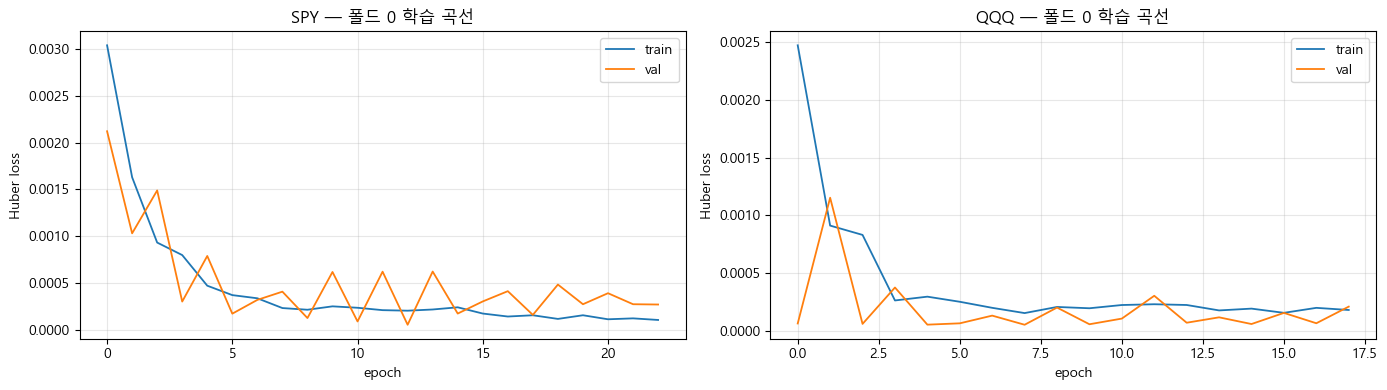

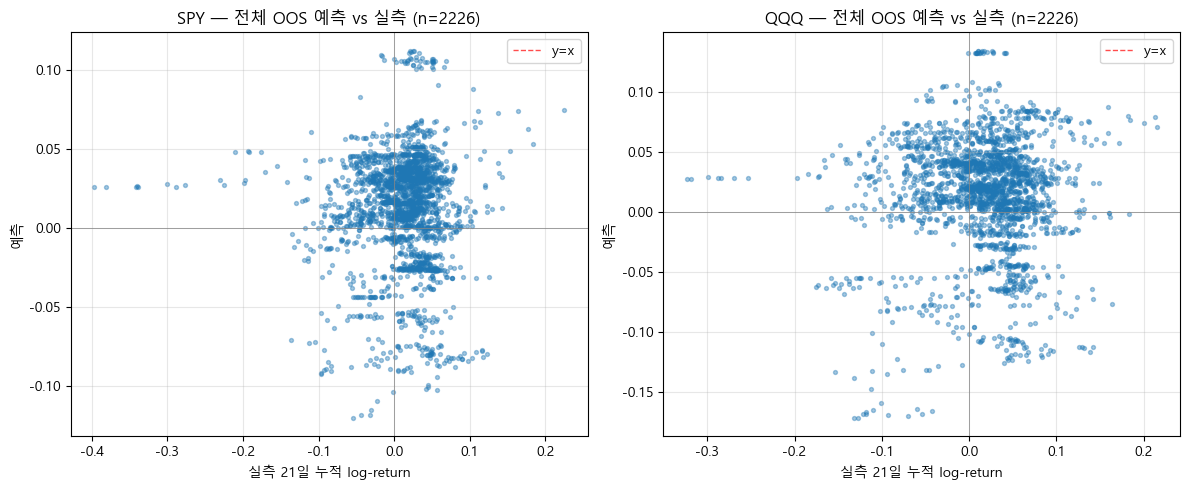

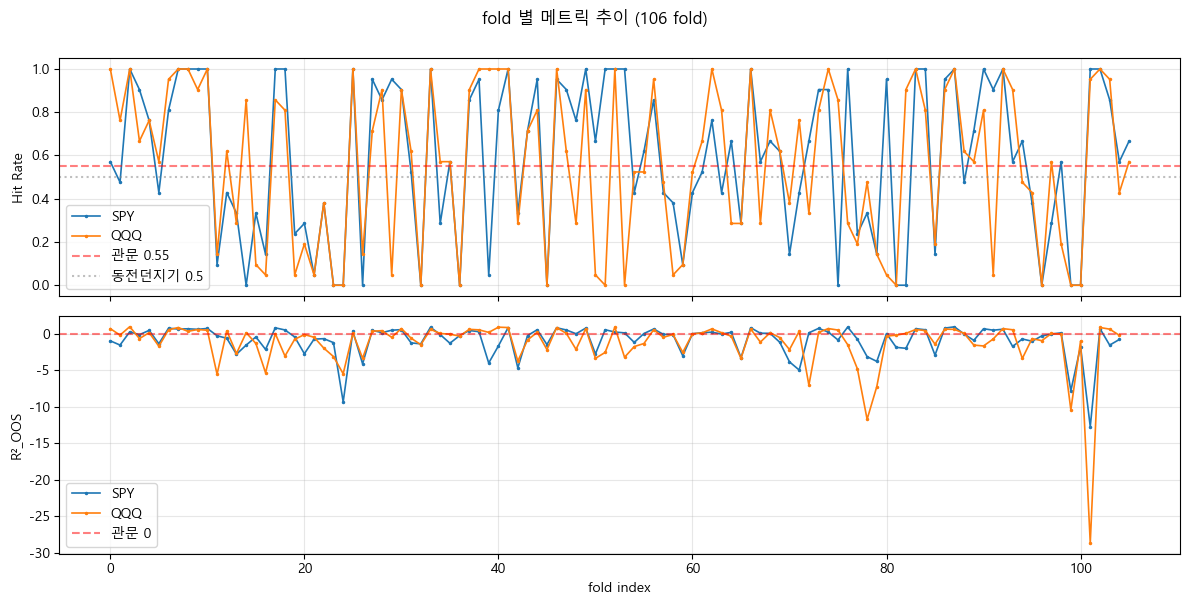


[§9] 평가·시각화 완료. 산출물:
  - C:\Users\gorhk\최종프로젝트\finance_project\시계열_Test\Phase1_LSTM\results\setting_A\SPY\metrics.json (fold 예측 포함, JSON 1개로 완전 재현 가능)
  - C:\Users\gorhk\최종프로젝트\finance_project\시계열_Test\Phase1_LSTM\results\setting_A\SPY\fold0_learning_curve.png
  - C:\Users\gorhk\최종프로젝트\finance_project\시계열_Test\Phase1_LSTM\results\setting_A\QQQ\metrics.json (fold 예측 포함, JSON 1개로 완전 재현 가능)
  - C:\Users\gorhk\최종프로젝트\finance_project\시계열_Test\Phase1_LSTM\results\setting_A\QQQ\fold0_learning_curve.png
  - C:\Users\gorhk\최종프로젝트\finance_project\시계열_Test\Phase1_LSTM\results\setting_A\pred_vs_actual.png
  - C:\Users\gorhk\최종프로젝트\finance_project\시계열_Test\Phase1_LSTM\results\setting_A\per_fold_metrics.png


In [15]:
# ===== §9 평가·시각화 =====
import json
import numpy as np
import matplotlib.pyplot as plt

from scripts.metrics import (
    hit_rate, r2_oos, r2_standard, mae, rmse,
    baseline_metrics, summarize_folds,
)


def compute_fold_metrics(fold_results):
    """fold 별 OOS 예측에 대해 5개 메트릭 계산."""
    out = []
    for fd in fold_results:
        yt, yp = fd['y_true'], fd['y_pred']
        out.append({
            'hit_rate':   hit_rate(yt, yp),
            'r2_oos':     r2_oos(yt, yp),
            'r2_std':     r2_standard(yt, yp),
            'mae':        mae(yt, yp),
            'rmse':       rmse(yt, yp),
            'best_epoch': fd['best_epoch'],
            'best_val':   fd['best_val_loss'],
        })
    return out


def _jsonify(o):
    """numpy 타입을 Python 기본형으로 재귀 변환 (JSON 직렬화 호환)."""
    if isinstance(o, dict):
        return {k: _jsonify(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_jsonify(v) for v in o]
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, np.bool_):
        return bool(o)
    return o


# --- 메트릭 집계 + baseline + 관문 판정 ---
FINAL_METRICS = {}
for ticker in ['SPY', 'QQQ']:
    fold_results = ALL_RESULTS[ticker]
    fold_metrics = compute_fold_metrics(fold_results)
    summary = summarize_folds(fold_metrics)

    y_true_all = np.concatenate([fd['y_true'] for fd in fold_results])
    y_pred_all = np.concatenate([fd['y_pred'] for fd in fold_results])
    y_train_all = targets_dict[ticker].dropna().values                  # baseline 참조용
    bl = baseline_metrics(y_true_all, y_train_all)

    # Phase 1 관문: Hit Rate > 0.55 AND R²_OOS > 0
    gate_hit = summary['hit_rate']['mean'] > 0.55
    gate_r2 = summary['r2_oos']['mean'] > 0
    gate_pass = gate_hit and gate_r2

    print(f'\n{"="*60}\n  [{ticker}] 최종 메트릭 요약 (n_folds={len(fold_results)})\n{"="*60}')
    for m in ['hit_rate', 'r2_oos', 'r2_std', 'mae', 'rmse']:
        s = summary[m]
        print(f'  {m:>10} : {s["mean"]:>+.6f} ± {s["std"]:.6f}  '
              f'[min={s["min"]:+.4f}, max={s["max"]:+.4f}, n={s["n"]}]')

    print(f'\n  관문  Hit Rate > 0.55  →  {summary["hit_rate"]["mean"]:.4f}  '
          + ('PASS' if gate_hit else 'FAIL'))
    print(f'  관문  R²_OOS   > 0     →  {summary["r2_oos"]["mean"]:.4f}  '
          + ('PASS' if gate_r2 else 'FAIL'))
    print(f'  종합 판정 (Phase 2 진행) : {"PASS" if gate_pass else "FAIL (재검토)"}')

    print(f'\n  Baseline 비교 (전체 OOS, n={len(y_true_all)}):')
    print(f'    {"baseline":<12}  {"hit_rate":>10}  {"r2_oos":>10}  {"mae":>10}  {"rmse":>10}')
    for name, m in bl.items():
        hr = f'{m["hit_rate"]:.4f}' if not np.isnan(m['hit_rate']) else '   nan'
        print(f'    {name:<12}  {hr:>10}  {m["r2_oos"]:>+10.4f}  '
              f'{m["mae"]:>10.6f}  {m["rmse"]:>10.6f}')

    # fold 별 예측 저장 — 모델 체크포인트를 버리는 대신 예측 배열로 재현성 확보
    fold_predictions = [
        {
            'k': int(fd['k']),
            'best_epoch': int(fd['best_epoch']),
            'best_val_loss': float(fd['best_val_loss']),
            'stopped_early': bool(fd['stopped_early']),
            'y_true': fd['y_true'].tolist(),
            'y_pred': fd['y_pred'].tolist(),
        }
        for fd in fold_results
    ]

    FINAL_METRICS[ticker] = {
        'summary': summary,
        'gate_pass': bool(gate_pass),
        'gate_hit_rate': bool(gate_hit),
        'gate_r2_oos': bool(gate_r2),
        'baseline': bl,
        'n_folds': len(fold_results),
        'n_oos_samples_total': int(len(y_true_all)),
        'hyperparams': {
            'seq_len': SEQ_LEN,
            'IS': IS, 'purge': PURGE, 'embargo': EMB, 'OOS': OOS, 'step': STEP,
            'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2,
            'loss': 'HuberLoss(delta=0.01)',
            'optimizer': 'AdamW(lr=1e-3, wd=1e-4)',
            'scheduler': 'ReduceLROnPlateau(patience=5, factor=0.5)',
            'max_epochs': 50, 'early_stop_patience': 10,
            'batch_size': 32, 'val_ratio': 0.2,
            'seed': 42,
        },
        'fold_predictions': fold_predictions,
    }

# --- metrics.json 저장 ---
for ticker, data in FINAL_METRICS.items():
    out_path = SETTING_A_DIR / ticker / 'metrics.json'
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(_jsonify(data), f, indent=2, ensure_ascii=False)
    size_kb = out_path.stat().st_size / 1024
    print(f'\n  [{ticker}] metrics.json 저장: {out_path}  ({size_kb:.1f} KB)')


# ===== 시각화 =====
# (1) 폴드 0 학습 곡선 — SPY·QQQ
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, ticker in zip(axes, ['SPY', 'QQQ']):
    hist = ALL_RESULTS[ticker][0]['history']
    ax.plot(hist['train_loss'], label='train', lw=1.3)
    ax.plot(hist['val_loss'], label='val', lw=1.3)
    ax.set_title(f'{ticker} — 폴드 0 학습 곡선')
    ax.set_xlabel('epoch'); ax.set_ylabel('Huber loss')
    ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
for ticker in ['SPY', 'QQQ']:
    fig.savefig(SETTING_A_DIR / ticker / 'fold0_learning_curve.png', dpi=100)
plt.show()

# (2) 예측 vs 실측 산점도 — SPY·QQQ
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ticker in zip(axes, ['SPY', 'QQQ']):
    y_true_all = np.concatenate([fd['y_true'] for fd in ALL_RESULTS[ticker]])
    y_pred_all = np.concatenate([fd['y_pred'] for fd in ALL_RESULTS[ticker]])
    ax.scatter(y_true_all, y_pred_all, s=8, alpha=0.4)
    lim = float(max(abs(y_true_all).max(), abs(y_pred_all).max()))
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1, alpha=0.7, label='y=x')
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(f'{ticker} — 전체 OOS 예측 vs 실측 (n={len(y_true_all)})')
    ax.set_xlabel('실측 21일 누적 log-return')
    ax.set_ylabel('예측'); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(SETTING_A_DIR / 'pred_vs_actual.png', dpi=100)
plt.show()

# (3) fold 별 메트릭 시계열 (hit_rate, r2_oos)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ticker, color in zip(['SPY', 'QQQ'], ['C0', 'C1']):
    fm = compute_fold_metrics(ALL_RESULTS[ticker])
    axes[0].plot([m['hit_rate'] for m in fm], label=ticker, color=color, lw=1.2, marker='.', ms=3)
    axes[1].plot([m['r2_oos'] for m in fm], label=ticker, color=color, lw=1.2, marker='.', ms=3)
axes[0].axhline(0.55, color='red', ls='--', alpha=0.5, label='관문 0.55')
axes[0].axhline(0.5, color='gray', ls=':', alpha=0.5, label='동전던지기 0.5')
axes[0].set_ylabel('Hit Rate'); axes[0].legend(loc='best'); axes[0].grid(alpha=0.3)
axes[1].axhline(0, color='red', ls='--', alpha=0.5, label='관문 0')
axes[1].set_ylabel('R²_OOS'); axes[1].set_xlabel('fold index')
axes[1].legend(loc='best'); axes[1].grid(alpha=0.3)
fig.suptitle('fold 별 메트릭 추이 (106 fold)', y=1.00)
fig.tight_layout()
fig.savefig(SETTING_A_DIR / 'per_fold_metrics.png', dpi=100)
plt.show()

print('\n[§9] 평가·시각화 완료. 산출물:')
for ticker in ['SPY', 'QQQ']:
    print(f'  - {SETTING_A_DIR / ticker / "metrics.json"} (fold 예측 포함, JSON 1개로 완전 재현 가능)')
    print(f'  - {SETTING_A_DIR / ticker / "fold0_learning_curve.png"}')
print(f'  - {SETTING_A_DIR / "pred_vs_actual.png"}')
print(f'  - {SETTING_A_DIR / "per_fold_metrics.png"}')

## §9.A. 학습곡선 갤러리 — 선택 fold (2순위 E)

**무엇을**: §9 에서는 fold 0 만 그렸지만, 학습 패턴이 fold 마다 어떻게 변하는지 확인하려면
여러 fold 의 train/val Huber loss 곡선을 함께 보아야 한다.

**왜**: §8 학습 로그에서 `best_ep=1` 로 끝난 fold (예: 1, 40, 60, 100) 가 다수 발견됨.
1 epoch 만에 best 가 나오는 건 학습이 거의 진행되지 못했다는 신호. fold 별 학습곡선을
직접 비교해 패턴을 파악한다.

**선택 fold**: 0, 25, 50, 75, 마지막 fold (시간 분포 균등 샘플).


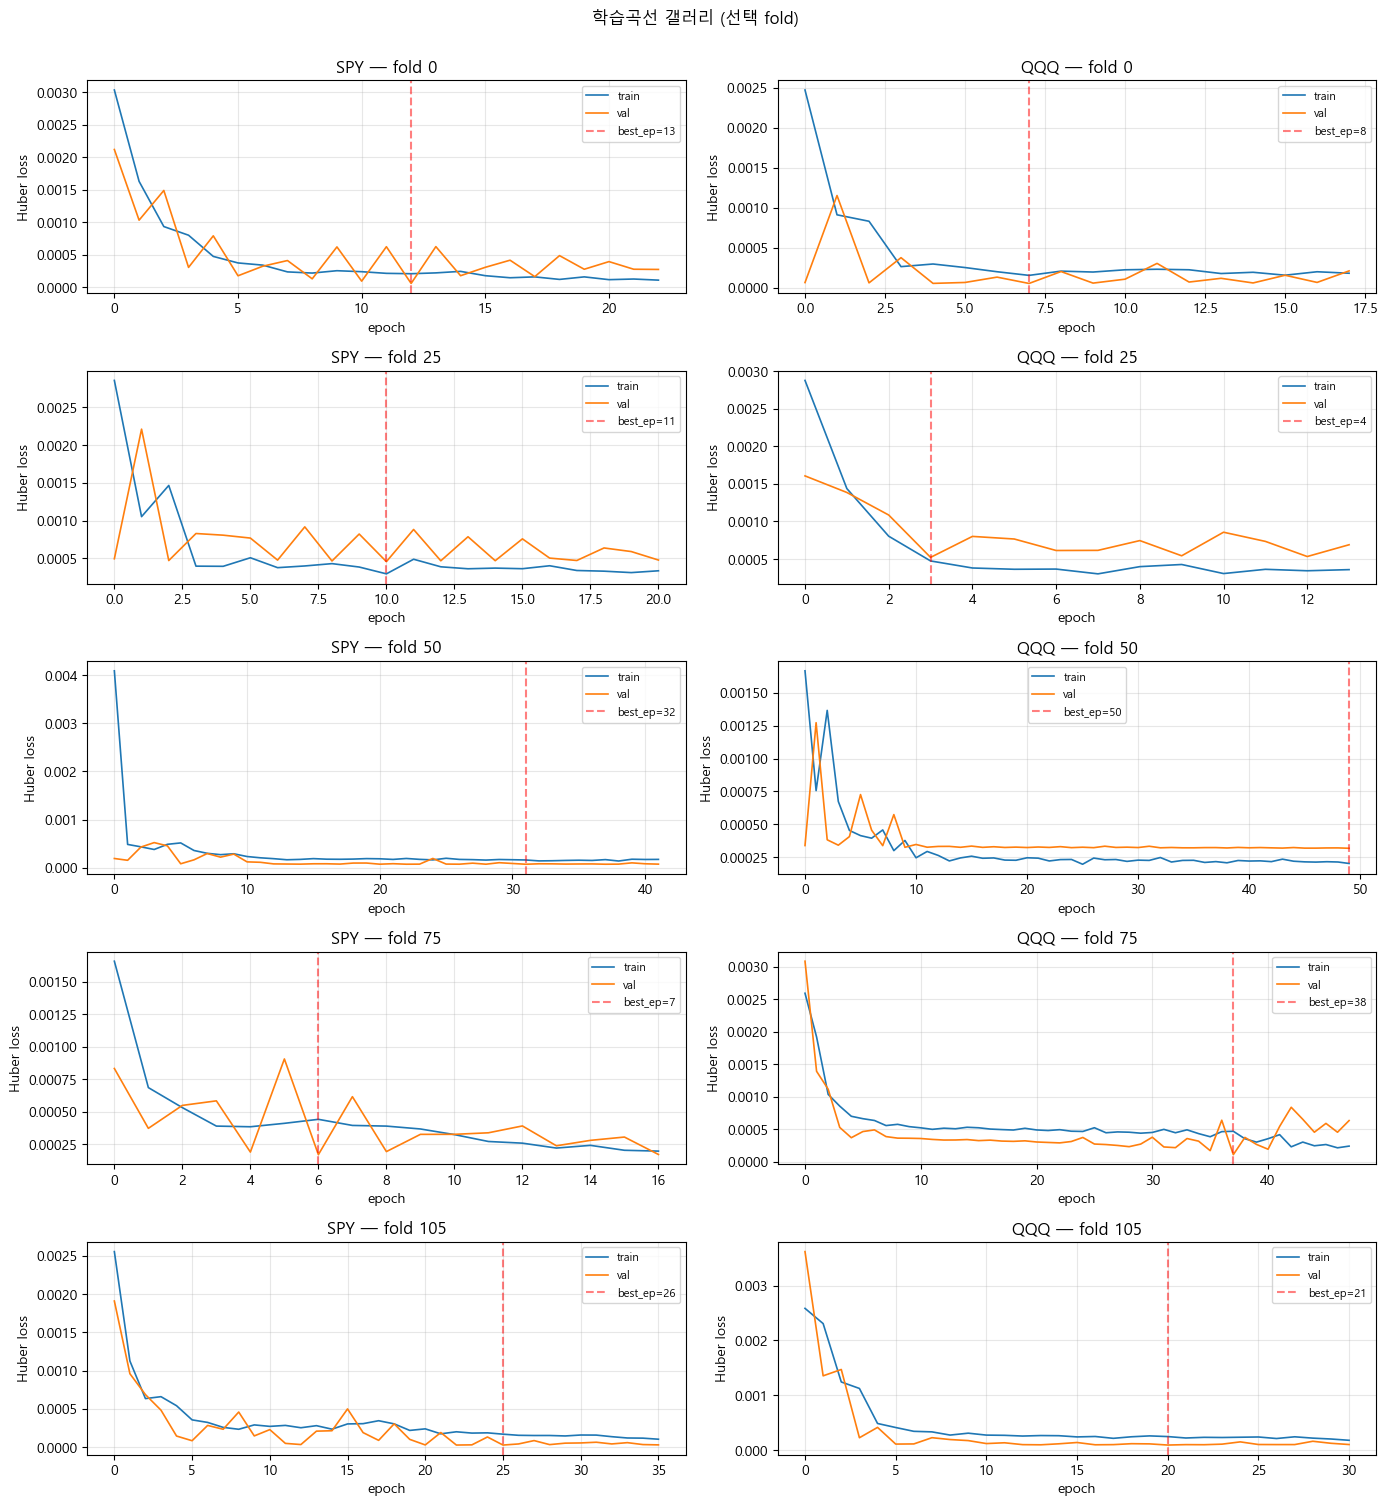

In [16]:
# §9.A — 학습곡선 갤러리 (선택 fold)
sample_folds_idx = [0, 25, 50, 75, len(ALL_RESULTS['SPY']) - 1]

fig, axes = plt.subplots(len(sample_folds_idx), 2,
                         figsize=(14, 3 * len(sample_folds_idx)),
                         sharex=False)
for row, fold_i in enumerate(sample_folds_idx):
    for col, ticker in enumerate(['SPY', 'QQQ']):
        ax = axes[row, col]
        hist = ALL_RESULTS[ticker][fold_i]['history']
        be = ALL_RESULTS[ticker][fold_i]['best_epoch']
        ax.plot(hist['train_loss'], label='train', lw=1.2)
        ax.plot(hist['val_loss'], label='val', lw=1.2)
        ax.axvline(be - 1, color='red', ls='--', alpha=0.5, label=f'best_ep={be}')
        ax.set_title(f'{ticker} — fold {fold_i}')
        ax.set_xlabel('epoch'); ax.set_ylabel('Huber loss')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle('학습곡선 갤러리 (선택 fold)', y=1.001)
fig.tight_layout()
fig.savefig(SETTING_A_DIR / 'learning_curve_gallery.png', dpi=100)
plt.show()


## §9.B. best_epoch 분포 — 학습 진행도 진단 (2순위 F)

**무엇을**: fold 별 best epoch (val loss 가 최저였던 시점) 의 분포를 확인한다.

**왜**: best_epoch 가 1~3 에 몰려 있으면 모델이 첫 몇 epoch 만에 val 에 적응한 후
그 뒤로 학습이 진행되지 못한 것 → 사실상 미학습 상태에 가까움.
중앙값과 `best_ep == 1` 비율을 출력한다.


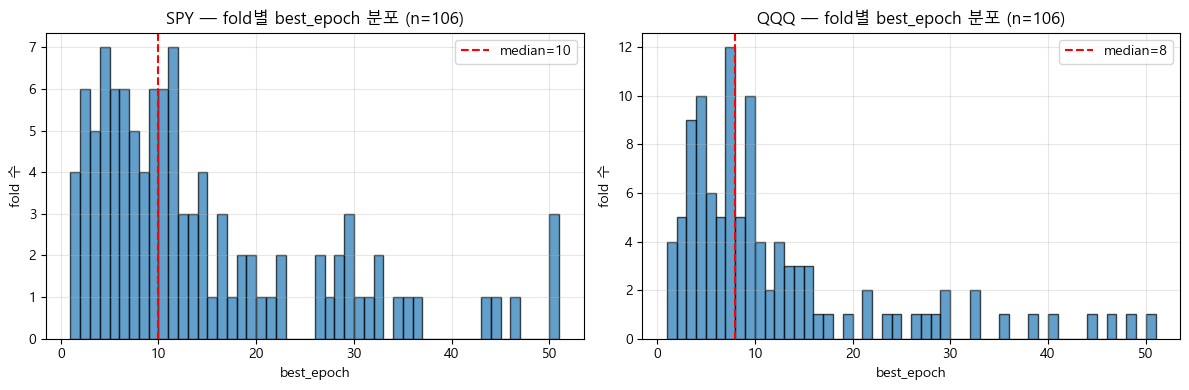


  SPY: best_epoch=1 fold = 4/106 (3.8%), best_epoch<=3 = 15/106 (14.2%)
  QQQ: best_epoch=1 fold = 4/106 (3.8%), best_epoch<=3 = 18/106 (17.0%)


In [17]:
# §9.B — best_epoch 분포 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, ticker in zip(axes, ['SPY', 'QQQ']):
    epochs = [fd['best_epoch'] for fd in ALL_RESULTS[ticker]]
    max_e = max(epochs)
    ax.hist(epochs, bins=range(1, max_e + 2), edgecolor='black', alpha=0.7)
    med = np.median(epochs)
    ax.axvline(med, color='red', ls='--', label=f'median={med:.0f}')
    ax.set_title(f'{ticker} — fold별 best_epoch 분포 (n={len(epochs)})')
    ax.set_xlabel('best_epoch'); ax.set_ylabel('fold 수')
    ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(SETTING_A_DIR / 'best_epoch_histogram.png', dpi=100)
plt.show()

# best_ep=1 비율 출력
print()
for ticker in ['SPY', 'QQQ']:
    epochs = [fd['best_epoch'] for fd in ALL_RESULTS[ticker]]
    n_one = sum(1 for e in epochs if e == 1)
    n_short = sum(1 for e in epochs if e <= 3)
    print(f'  {ticker}: best_epoch=1 fold = {n_one}/{len(epochs)} '
          f'({n_one/len(epochs)*100:.1f}%), '
          f'best_epoch<=3 = {n_short}/{len(epochs)} '
          f'({n_short/len(epochs)*100:.1f}%)')


## §9.C. 예측 분포 sanity — mean-prediction collapse 검출 (1순위 C)

**무엇을**: 모델이 거의 일정한 값(예: train mean) 만 출력하는 "collapse" 상태인지 확인.

**왜**: hit_rate 가 0.64 라도 모델이 거의 항상 비슷한 양수만 출력하면 부호 일치는 우연.
- `pred.std() / true.std()` 비율이 0.5 미만이면 collapse 의심
- 분포 히스토그램으로 모양도 직접 비교

**진단 결과**: 콘솔에 `pred_std/true_std` 출력. 0.5 미만이면 ⚠️ 표시.


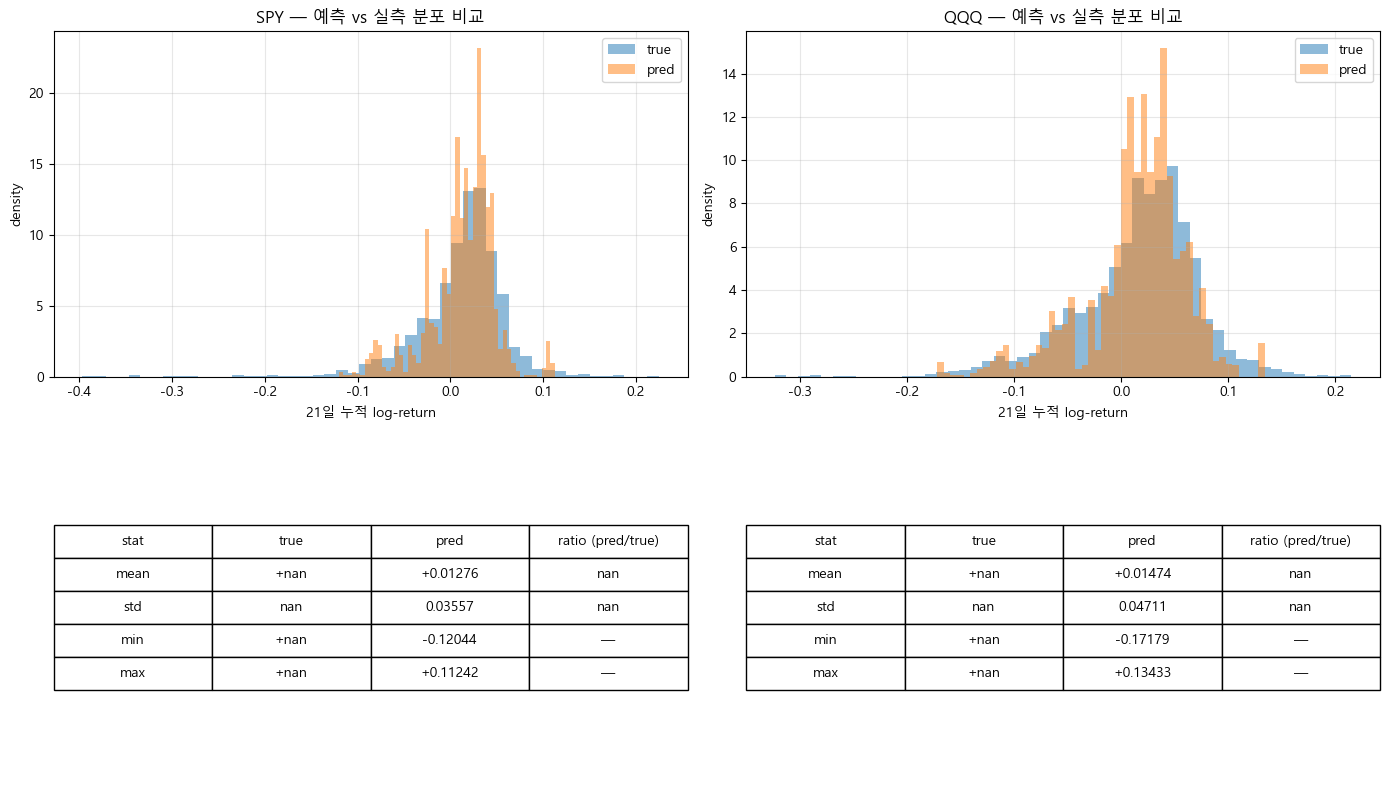


  SPY: pred_std/true_std = nan  → ✅ 정상
  QQQ: pred_std/true_std = nan  → ✅ 정상


In [18]:
# §9.C — 예측 분포 sanity
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, ticker in enumerate(['SPY', 'QQQ']):
    fold_results = ALL_RESULTS[ticker]
    y_true = np.concatenate([fd['y_true'] for fd in fold_results])
    y_pred = np.concatenate([fd['y_pred'] for fd in fold_results])

    # 상단: 분포 비교 히스토그램
    ax_h = axes[0, col]
    ax_h.hist(y_true, bins=50, alpha=0.5, label='true', density=True)
    ax_h.hist(y_pred, bins=50, alpha=0.5, label='pred', density=True)
    ax_h.set_title(f'{ticker} — 예측 vs 실측 분포 비교')
    ax_h.set_xlabel('21일 누적 log-return'); ax_h.set_ylabel('density')
    ax_h.legend(); ax_h.grid(alpha=0.3)

    # 하단: 통계 요약 표
    ax_t = axes[1, col]
    ax_t.axis('off')
    rows = [
        ['stat', 'true', 'pred', 'ratio (pred/true)'],
        ['mean', f'{y_true.mean():+.5f}', f'{y_pred.mean():+.5f}',
         (f'{y_pred.mean()/y_true.mean():.3f}' if y_true.mean() != 0 else 'n/a')],
        ['std',  f'{y_true.std():.5f}',  f'{y_pred.std():.5f}',
         f'{y_pred.std()/y_true.std():.3f}'],
        ['min',  f'{y_true.min():+.5f}', f'{y_pred.min():+.5f}', '—'],
        ['max',  f'{y_true.max():+.5f}', f'{y_pred.max():+.5f}', '—'],
    ]
    table = ax_t.table(cellText=rows[1:], colLabels=rows[0],
                       cellLoc='center', loc='center')
    table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1, 1.6)

fig.tight_layout()
fig.savefig(SETTING_A_DIR / 'prediction_distribution.png', dpi=100)
plt.show()

# 진단 출력
print()
for ticker in ['SPY', 'QQQ']:
    fold_results = ALL_RESULTS[ticker]
    y_true = np.concatenate([fd['y_true'] for fd in fold_results])
    y_pred = np.concatenate([fd['y_pred'] for fd in fold_results])
    ratio = y_pred.std() / y_true.std()
    flag = '⚠️ COLLAPSE 의심 (pred_std < 0.5 × true_std)' if ratio < 0.5 else '✅ 정상'
    print(f'  {ticker}: pred_std/true_std = {ratio:.3f}  → {flag}')


## §9.D. 잔차 시계열 + 부호 혼동행렬 (2순위 G)

**무엇을**:
- 잔차 (`true - pred`) 의 시간 추이 → 체제 전환·systematic bias 검출
- 2x2 부호 혼동행렬 → 모델이 어느 방향으로 편향됐는지 확인

**왜**: 잔차에 시간적 패턴이 있으면 missing feature 의 신호.
부호 혼동행렬에서 한쪽 셀에 몰리면 모델이 "항상 양수" 같은 trivial 답을 내고 있음.

**산출물**: `residual_and_confusion.png`


C:\Users\gorhk\AppData\Local\Temp\ipykernel_55444\15271277.py:38: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.tight_layout()
C:\Users\gorhk\AppData\Local\Temp\ipykernel_55444\15271277.py:39: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.savefig(SETTING_A_DIR / 'residual_and_confusion.png', dpi=100)
c:\Users\gorhk\최종프로젝트\finance_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


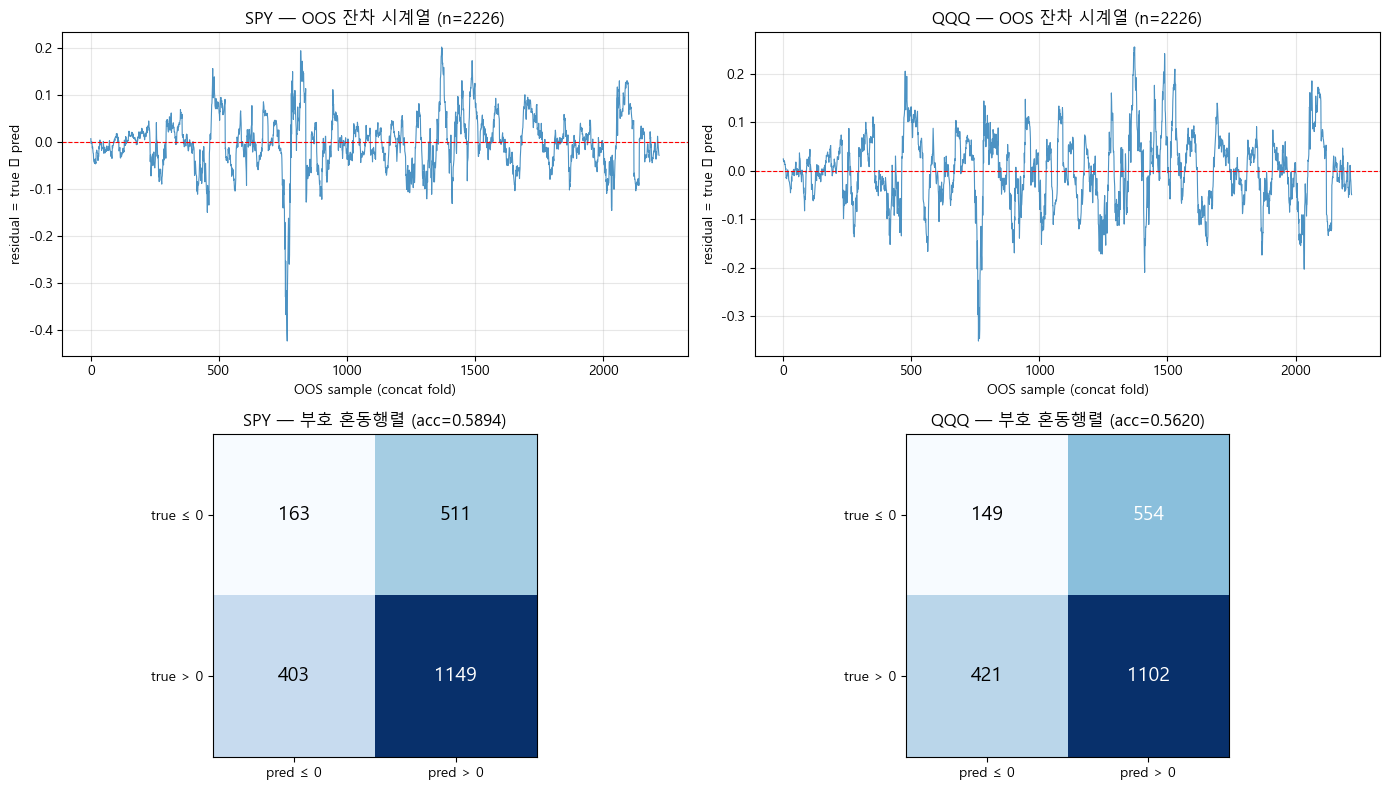

In [19]:
# §9.D — 잔차 시계열 + 부호 혼동행렬
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, ticker in enumerate(['SPY', 'QQQ']):
    fold_results = ALL_RESULTS[ticker]
    y_true = np.concatenate([fd['y_true'] for fd in fold_results])
    y_pred = np.concatenate([fd['y_pred'] for fd in fold_results])
    residual = y_true - y_pred

    # 상단: 잔차 시계열
    ax_res = axes[0, col]
    ax_res.plot(residual, lw=0.8, alpha=0.8)
    ax_res.axhline(0, color='red', ls='--', lw=0.8)
    ax_res.set_title(f'{ticker} — OOS 잔차 시계열 (n={len(residual)})')
    ax_res.set_xlabel('OOS sample (concat fold)')
    ax_res.set_ylabel('residual = true − pred')
    ax_res.grid(alpha=0.3)

    # 하단: 부호 혼동행렬 2x2
    ax_conf = axes[1, col]
    tt = (y_true > 0).astype(int)
    pp = (y_pred > 0).astype(int)
    cm = np.zeros((2, 2), dtype=int)
    for t, p in zip(tt, pp):
        cm[t, p] += 1
    ax_conf.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax_conf.text(j, i, str(cm[i, j]), ha='center', va='center',
                         color=color, fontsize=14)
    ax_conf.set_xticks([0, 1]); ax_conf.set_yticks([0, 1])
    ax_conf.set_xticklabels(['pred ≤ 0', 'pred > 0'])
    ax_conf.set_yticklabels(['true ≤ 0', 'true > 0'])
    acc = (cm[0, 0] + cm[1, 1]) / cm.sum() if cm.sum() > 0 else float('nan')
    ax_conf.set_title(f'{ticker} — 부호 혼동행렬 (acc={acc:.4f})')

fig.tight_layout()
fig.savefig(SETTING_A_DIR / 'residual_and_confusion.png', dpi=100)
plt.show()


## §9.E. fold별 R²_OOS / Hit Rate 박스플롯 (2순위 H)

**무엇을**: §9 의 시계열 plot 대신 분포 형태(중앙값·IQR·outlier) 를 박스플롯으로 본다.

**왜**: 평균값만 보면 outlier (예: R² min = -37) 가 평균을 크게 끌어내리는 효과가 묻힌다.
박스플롯으로 중앙값·사분위수·outlier 분포를 한눈에 확인한다.

**산출물**: `metric_boxplots.png`


C:\Users\gorhk\AppData\Local\Temp\ipykernel_55444\3227224499.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([r2_data['SPY'], r2_data['QQQ']],
C:\Users\gorhk\AppData\Local\Temp\ipykernel_55444\3227224499.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([hit_data['SPY'], hit_data['QQQ']],


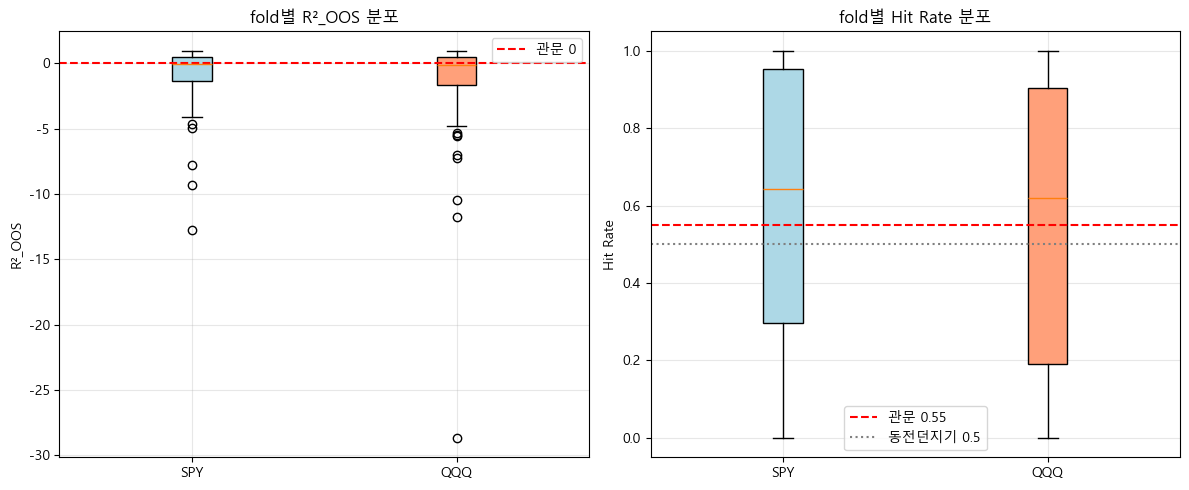

In [20]:
# §9.E — fold별 R²_OOS / Hit Rate 박스플롯
r2_data = {}
hit_data = {}
for ticker in ['SPY', 'QQQ']:
    fm = compute_fold_metrics(ALL_RESULTS[ticker])
    r2_data[ticker] = [m['r2_oos'] for m in fm if not np.isnan(m['r2_oos'])]
    hit_data[ticker] = [m['hit_rate'] for m in fm if not np.isnan(m['hit_rate'])]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R²_OOS 박스플롯
ax = axes[0]
bp = ax.boxplot([r2_data['SPY'], r2_data['QQQ']],
                labels=['SPY', 'QQQ'], showfliers=True, patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightsalmon']):
    patch.set_facecolor(color)
ax.axhline(0, color='red', ls='--', label='관문 0')
ax.set_title('fold별 R²_OOS 분포')
ax.set_ylabel('R²_OOS'); ax.legend(); ax.grid(alpha=0.3)

# Hit Rate 박스플롯
ax = axes[1]
bp = ax.boxplot([hit_data['SPY'], hit_data['QQQ']],
                labels=['SPY', 'QQQ'], showfliers=True, patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightsalmon']):
    patch.set_facecolor(color)
ax.axhline(0.55, color='red', ls='--', label='관문 0.55')
ax.axhline(0.5, color='gray', ls=':', label='동전던지기 0.5')
ax.set_title('fold별 Hit Rate 분포')
ax.set_ylabel('Hit Rate'); ax.legend(); ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(SETTING_A_DIR / 'metric_boxplots.png', dpi=100)
plt.show()


## §9.F. Train / Val / Test 동일지표 비교 — 과적합 정량 진단 (1순위 A)

**무엇을**: §8 에서 fold 별 best 모델로 train/val/test 모두에 대한 예측을 수집했다.
이를 동일 메트릭(hit_rate, r²_oos, mae, rmse) 으로 한 표에 비교한다.

**왜**: 기존 §9 는 test (OOS) 메트릭만 계산하고 train/val 은 Huber loss 만 보여줬다.
- train/val 의 Huber loss 가 낮은 것은 "회귀 오차가 작다" 일 뿐, "방향 예측이 잘 된다" 는 아님
- 동일 지표로 train→val→test 변화를 보면 과적합 갭(hit_rate 차이, r²_oos 차이) 을 정량 측정 가능

**예상**: 과적합이 심하면 train hit_rate >> val/test hit_rate. 반대로 train hit_rate 도 낮으면
underfit 또는 mean-collapse. 두 시나리오는 처방이 다르다.

**산출물**: 콘솔 표 + `overfit_gap.png`



  Train / Val / Test 동일지표 비교 (best 모델 기준, fold 평균±표준편차)
ticker set                hit_rate                r2_oos             mae            rmse
--------------------------------------------------------------------------------------------
SPY    train  +0.6164±0.250    -0.3627±1.510    0.038339    0.046529
SPY    val    +0.8531±0.165    +0.5856±0.334    0.019874    0.024394
SPY    test   +0.5894±0.359    -0.8512±2.122    0.042853    0.047444
--------------------------------------------------------------------------------------------
QQQ    train  +0.6271±0.243    -0.3995±1.522    0.048730    0.059219
QQQ    val    +0.8383±0.205    +0.5607±0.361    0.025996    0.031818
QQQ    test   +0.5620±0.366    -1.2562±3.519    0.057056    0.062963
--------------------------------------------------------------------------------------------


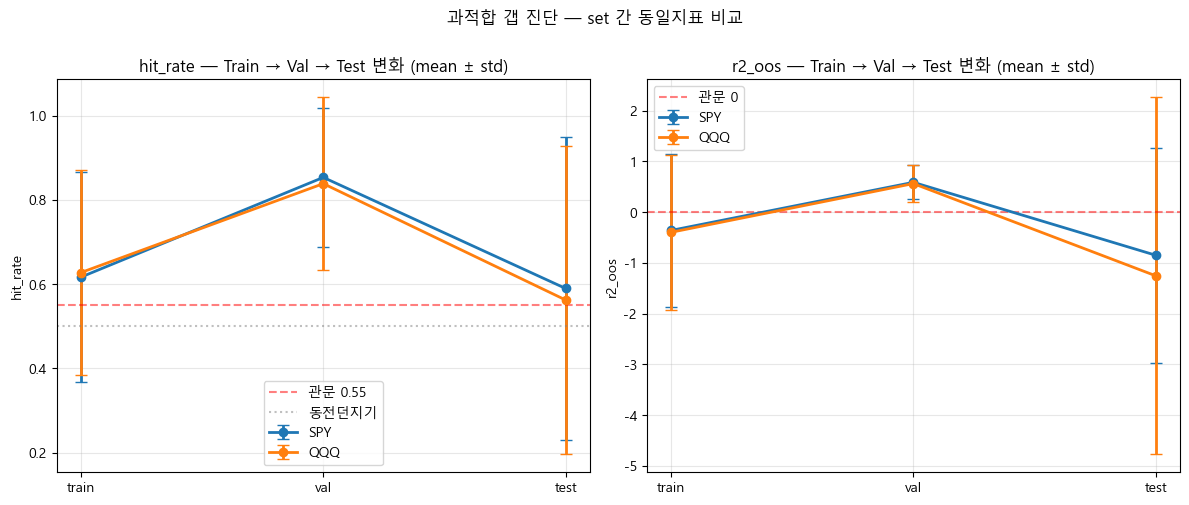

In [21]:
# §9.F — Train/Val/Test 동일지표 비교 (1순위 A)
def metrics_for_set(fold_results, set_name):
    """fold 별 (y_true_{set}, y_pred_{set}) 에 대해 메트릭 산출 후 fold 통계 요약."""
    out = []
    for fd in fold_results:
        if set_name == 'test':
            yt, yp = fd['y_true'], fd['y_pred']
        else:
            yt, yp = fd[f'y_true_{set_name}'], fd[f'y_pred_{set_name}']
        out.append({
            'hit_rate': hit_rate(yt, yp),
            'r2_oos':   r2_oos(yt, yp),
            'mae':      mae(yt, yp),
            'rmse':     rmse(yt, yp),
        })
    return summarize_folds(out)


# 콘솔 표 출력
print()
print('=' * 92)
print('  Train / Val / Test 동일지표 비교 (best 모델 기준, fold 평균±표준편차)')
print('=' * 92)
header = f'{"ticker":<7}{"set":<7}{"hit_rate":>20}{"r2_oos":>22}{"mae":>16}{"rmse":>16}'
print(header)
print('-' * 92)
SET_NAMES = ['train', 'val', 'test']
for ticker in ['SPY', 'QQQ']:
    for set_name in SET_NAMES:
        s = metrics_for_set(ALL_RESULTS[ticker], set_name)
        hr, r2 = s['hit_rate'], s['r2_oos']
        ma, rm = s['mae'], s['rmse']
        print(f'{ticker:<7}{set_name:<7}'
              f'{hr["mean"]:+.4f}±{hr["std"]:.3f}    '
              f'{r2["mean"]:+.4f}±{r2["std"]:.3f}    '
              f'{ma["mean"]:.6f}    '
              f'{rm["mean"]:.6f}')
    print('-' * 92)

# 과적합 갭 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric in zip(axes, ['hit_rate', 'r2_oos']):
    for ticker, color in zip(['SPY', 'QQQ'], ['C0', 'C1']):
        means, stds = [], []
        for set_name in SET_NAMES:
            s = metrics_for_set(ALL_RESULTS[ticker], set_name)
            means.append(s[metric]['mean'])
            stds.append(s[metric]['std'])
        ax.errorbar(SET_NAMES, means, yerr=stds, marker='o', lw=2,
                    label=ticker, color=color, capsize=4)
    if metric == 'hit_rate':
        ax.axhline(0.55, color='red', ls='--', alpha=0.5, label='관문 0.55')
        ax.axhline(0.5, color='gray', ls=':', alpha=0.5, label='동전던지기')
    elif metric == 'r2_oos':
        ax.axhline(0, color='red', ls='--', alpha=0.5, label='관문 0')
    ax.set_title(f'{metric} — Train → Val → Test 변화 (mean ± std)')
    ax.set_ylabel(metric); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle('과적합 갭 진단 — set 간 동일지표 비교', y=1.001)
fig.tight_layout()
fig.savefig(SETTING_A_DIR / 'overfit_gap.png', dpi=100)
plt.show()


## §10. 결론·체크포인트

### §1~§9 완료 사항 요약

| 항목 | 결과 |
|---|---|
| 분석 기간 | 2016-01-04 ~ 2025-12-31, SPY·QQQ 각 2514행 |
| log_return NaN | 0 (분석 기간 내) |
| 타깃 유효 행 | 2493개 (NaN 21개: 마지막 21행) |
| 누수 검증 1·2 | SPY·QQQ 모두 Assert PASS + 육안 표 확인 |
| seq_len | **126** (Setting A 확정) |
| 폴드 수 | **106** (SPY·QQQ 동일) |
| 훈련 샘플/폴드 | **105** (IS 231 − seq_len 126) → train 80% / val 20% (시간순) |
| 테스트 샘플/폴드 | **21** (OOS 21) |
| LSTM 구조 | hidden=128, 2-layer, dropout=0.2, `batch_first=True` |
| 파라미터 수 | 199,297개 |
| 학습 구성 | Huber(δ=0.01) / AdamW(lr=1e-3, wd=1e-4) / ReduceLROnPlateau / clip=1.0 / EarlyStop=10 |
| Device | cuda > mps > cpu 자동 감지 (`get_device('auto')`) |

### 산출물 (Run All 실행 시 자동 생성)

```
results/setting_A/
├── SPY/
│   ├── metrics.json                   ← 집계 메트릭 + 관문 + 하이퍼 + fold 예측 배열
│   └── fold0_learning_curve.png
├── QQQ/
│   └── (동일 구조)
├── pred_vs_actual.png                ← 전체 OOS 산점도
└── per_fold_metrics.png              ← fold 별 hit_rate, R²_OOS 추이
```

**실무 관행 반영** (2026-04-25 변경): Walk-Forward 의 각 fold 모델(`state_dict`) 은 일회용이므로 디스크에 저장하지 않는다. 대신 fold 별 `y_true`, `y_pred` 배열을 `metrics.json` 에 포함시켜 메트릭·플롯 재생산을 보장한다. 모델이 필요한 시나리오는 seed 가 고정되어 있어 재학습으로 복원 가능하다.

### 관문 판정 (§9 셀 출력 참조)

- **Hit Rate > 0.55** AND **R²_OOS > 0** 둘 다 충족 시 PASS → Phase 2 (GRU) 진행 권고
- FAIL 시 모델·피처 재검토. 학습자료_주의사항 §6.5 주의 — 통계 유의 ≠ 경제 의미

### 학습자료_주의사항 준수 현황

| 항목 | 상태 |
|---|---|
| 1.3 Normalization Leakage | ✅ `scaler.fit(train_idx)` only |
| 1.4 Window Leakage | ✅ purge+embargo 시간 기반 분리 |
| 1.5 Walk-Forward purge+embargo | ✅ purge=21, emb=21 적용 |
| 2.2 log-return 사용 | ✅ `np.log(Adj Close).diff()` |
| 3.3 (B,T,F) 축 계약 | ✅ `batch_first=True` (§5·§7) |
| 3.6 학습 루프 10가지 함정 | ✅ `scripts/train.py` 에서 모두 방어 (zero_grad, eval, no_grad, clip_grad, item detach) |
| 4.4 1-layer dropout 함정 | ✅ `scripts/models.py` 에서 별도 `nn.Dropout` 우회 |
| 7.1 fit/transform 분리 | ✅ `build_fold_datasets` 내 분리 |
| 6.5 통계 유의 ≠ 경제 의미 | ✅ `scripts/metrics.py` docstring 에 인용 |

### 다음 단계

1. 본 노트북 Run All 실행 → `results/setting_A/{SPY,QQQ}/metrics.json` 생성 (CPU 10~30분 / GPU 2~5분)
2. `03_setting_B_monthly.ipynb` — 월별 1개월 예측 (월별 fold, `build_monthly_target_1m` 사용)
3. `04_compare_A_vs_B.ipynb` — 설정 A·B 비교 + Phase 2 진행 여부 최종 판정 + `comparison_report.md` 자동 생성

### WORKLOG 업데이트 (Run 후)

실행 완료 후 다음 항목을 `재천_WORKLOG.md` 에 기록:
- SPY·QQQ 관문 판정 결과 (PASS/FAIL)
- Hit Rate / R²_OOS 평균±표준편차
- Baseline 대비 개선 폭
- 의외 발견 (과적합 신호, fold 간 분산 등)